---
## 🎁 가산점 항목 및 요구사항 반영 요약

### A. 데이터의 다양성 및 15개 전체 데이터셋 정밀 분석
- **15개 전체 데이터셋 진단 스캔:** `dataset` 디렉토리에 존재하는 모든 화학 데이터셋(15개)을 실시간으로 고속 스캔하여 전체 행 수, 컬럼 프로필, SMILES 구조 내장 여부 등을 요약 테이블과 시각화로 분석한다.
- **최적의 QSAR 데이터셋 선별:** 스캔 결과를 바탕으로 사용 가능한 고유 샘플 수, 클래스 균형성(Class Imbalance), 그리고 생물학적 가치(발암성 예측의 중요성)를 고려하여 최종 모델링용 데이터셋으로 `cancer.xlsx`(발암성 데이터셋)를 선정한다.
- **PubChem REST API Fallback 시스템 내장:** SMILES 구조가 부재한 화합물이 입력되거나 결측치가 존재할 때, PubChem REST API를 호출하여 화학물질명 기반으로 Canonical SMILES를 온라인에서 실시간으로 추적하는 Fallback 시스템을 구현한다.

### B. Feature(descriptor)의 다양성 및 멀티코어 병렬 연산 가속
- **물리화학적 Descriptor 및 6대 분자 지문 (Fingerprints) 추출:** RDKit 기본 2D Molecular Descriptor(200여 개)뿐만 아니라, RDKit의 대표적인 6대 분자 지문(Morgan, Path-based, MACCS, Atom Pairs, Topological Torsion, Pattern)을 전량 추출하여 가로로 병합한다.
- **접두사(Prefix) 피처 명명법:** 결합된 피처 컬럼의 출처를 쉽게 구분할 수 있도록 각각 `Morgan_`, `RDKit_`, `MACCS_`, `AtomPair_`, `Torsion_`, `Pattern_` 접두사를 동적으로 부여하여 특징 행렬을 구축한다.
- **Joblib 멀티프로세싱 CPU 병렬 가속:** 디스크립터 및 분자 지문 계산 과정에 `joblib` 기반의 멀티코어 병렬 연산(`n_jobs=-1`)을 적용하여 대용량 화학 데이터의 피처 추출 시간을 획득한다.

### C. 학술 논문 규격 시각화 (Data Pipeline)
- **[학술 시각화 1] 데이터셋 진단 스캔 결과 요약:** 15개 전체 데이터셋의 크기, 구조 보유율, Mixture 유무를 2x2 subplot 그리드로 분석한다.
- **[학술 시각화 2] 데이터 필터링 흐름도 (Data Flowchart):** 엑셀 로드부터 다단계 중복 및 무기염 제거를 거쳐 최종 2,270개 화합물에 이르기까지의 단계별 샘플 수와 사유를 Matplotlib FancyBboxPatch 다이어그램으로 도식화한다.


# 기말고사 Template 1 — Data Pipeline (발암성 QSAR 데이터 정화 및 피처 추출 엔진)

**이름:** 김나연 &nbsp; **학번:** 20250786 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |


In [7]:
# =========================================================================
# 🧪 QSAR 모델 구축 및 검증을 위한 필수 라이브러리 로드 및 경고 억제
# =========================================================================
import os
import glob
import openpyxl
import requests
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from rdkit.Chem.SaltRemover import SaltRemover
from joblib import Parallel, delayed

# Matplotlib 글꼴 누락 경고 및 불필요한 FutureWarning 억제
warnings.filterwarnings("ignore", category=UserWarning, message=".*Glyph.*")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")


In [8]:
# =========================================================================
# 🎨 시각화 한글 폰트 및 마이너스 기호 깨짐 방지 설정
# =========================================================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


## [지시사항 1] 데이터 탐색(EDA) 및 데이터·모델 선정 전략

### 1. 전체 15개 화학 데이터셋 실시간 고속 스캔 및 다각적 시각화 (EDA)
- `dataset` 폴더 내에 존재하는 15개 전체 엑셀 데이터셋을 실시간으로 고속 진단(Diagnostic Scan)한다.
- 각 파일의 전체 행 수, 컬럼 수, SMILES 구조식 내장 여부, Mixture 유무, 라벨 컬럼 정보를 요약 표로 출력하고 비교 그래프로 시각화한다.


In [ ]:
# =========================================================================
# ?? 1. 'dataset/' ?? ? ?? ?? ???? ?? ?? ??
# =========================================================================
import os
import glob
import openpyxl

base_dir = os.getcwd()
if not os.path.isdir(os.path.join(base_dir, 'dataset')):
    alt_dir = os.path.join(base_dir, 'ny', 'ML')
    if os.path.isdir(os.path.join(alt_dir, 'dataset')):
        base_dir = alt_dir

files = glob.glob(os.path.join(base_dir, 'dataset', '*.xlsx'))
scan_results = []

print(f"?? 'dataset/' ?? ? ? {len(files)}?? ?? ?? ?? ??? ?????.")

for f in files:
    bn = os.path.basename(f)
    try:
        wb = openpyxl.load_workbook(f, read_only=True, data_only=True)
        sheets = wb.sheetnames
        t_sheet = next((s for s in ['Table S1', 'A. DIRIL (317)', 'version 2', 'Data_invivo', 'Data', 'Data_invitro'] if s in sheets), sheets[0])
        ws = wb[t_sheet]
        max_r = ws.max_row or sum(1 for _ in ws.iter_rows(values_only=True))
        wb.close()

        h_val = 1 if 'Drug Induced Liver Injury' in bn else 0
        df_head = pd.read_excel(f, sheet_name=t_sheet, header=h_val, nrows=1)
        smi_col = next((c for c in df_head.columns if str(c).lower() in ['smiles', 'smi', 'smile']), None)
        mix_col = next((c for c in df_head.columns if str(c).lower() == 'mixture'), None)
        total_rows = max_r - (1 if h_val > 0 else 0)

        smiles_count = 0
        chemical_count = 0
        note = 'SMILES ??'

        if smi_col:
            smiles_df = pd.read_excel(f, sheet_name=t_sheet, header=h_val, usecols=[smi_col])
            smiles_valid = smiles_df[smiles_df[smi_col].notna()].copy()
            smiles_valid = smiles_valid[smiles_valid[smi_col].astype(str).str.strip() != '']
            smiles_count = len(smiles_valid)
            note = 'SMILES ??? ??'

            if mix_col:
                mix_df = pd.read_excel(f, sheet_name=t_sheet, header=h_val, usecols=[mix_col])
                chemical_count = int((mix_df[mix_col].astype(str).str.strip().str.lower() == 'chemical').sum())
                note = 'SMILES + Chemical ??? ??'
            else:
                chemical_count = smiles_count
                note = 'Mixture ??, SMILES ?? ??'

        scan_results.append({
            '???': bn,
            '?????': t_sheet,
            '????': total_rows,
            '??': len(df_head.columns),
            'SMILES????': smiles_count,
            'Chemical????': chemical_count,
            'SMILES??': smi_col is not None,
            'Mixture??': mix_col is not None,
            '??': note,
        })
    except Exception as e:
        scan_results.append({
            '???': bn,
            '?????': '',
            '????': 0,
            '??': 0,
            'SMILES????': 0,
            'Chemical????': 0,
            'SMILES??': False,
            'Mixture??': False,
            '??': f'?? ??: {e}',
        })

df_scan = pd.DataFrame(scan_results)
display(df_scan)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import platform

if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

if 'df_scan' not in globals():
    raise NameError('df_scan is not defined. Run the scan cell first.')

def shorten_name(name):
    name = str(name).replace('.xlsx', '')
    return name[:22] + '...' if len(name) > 22 else name

df_scan_plot = df_scan.copy()
df_scan_plot['?????'] = df_scan_plot['???'].apply(shorten_name)

color_map = dict(zip(df_scan_plot['?????'], sns.color_palette('tab20', n_colors=len(df_scan_plot))))

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('?? ???? ?? ?? ? 4? ?? ?? ??', fontsize=18, fontweight='bold', color='#1a365d')

# 1. ?? ?? ?
df_total = df_scan_plot.sort_values(by='????', ascending=False)
sns.barplot(x='????', y='?????', data=df_total, ax=axes[0,0],
            palette=color_map, hue='?????', legend=False)
axes[0,0].set_xscale('log')
axes[0,0].set_title('1. ?? ?? ?', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('?? ? ? (Log)')
axes[0,0].set_ylabel('????')
for i, v in enumerate(df_total['????']):
    axes[0,0].text(v * 1.08, i, f'{int(v):,}', va='center', fontsize=9, fontweight='bold')

# 2. SMILES ??? ?? ?? ?
df_smiles = df_scan_plot.sort_values(by='SMILES????', ascending=False)
sns.barplot(x='SMILES????', y='?????', data=df_smiles, ax=axes[0,1],
            palette=color_map, hue='?????', legend=False)
axes[0,1].set_xscale('log')
axes[0,1].set_title('2. SMILES ??? ?? ?? ?', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('SMILES ?? ?? ? (Log)')
axes[0,1].set_ylabel('')
for i, v in enumerate(df_smiles['SMILES????']):
    axes[0,1].text(v * 1.08, i, f'{int(v):,}', va='center', fontsize=9, fontweight='bold')

# 3. Chemical? ? ?? ?
df_chem = df_scan_plot.sort_values(by='Chemical????', ascending=False)
sns.barplot(x='Chemical????', y='?????', data=df_chem, ax=axes[1,0],
            palette=color_map, hue='?????', legend=False)
axes[1,0].set_xscale('log')
axes[1,0].set_title('3. Chemical? ? ?? ?', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Chemical ?? ?? ? (Log)')
axes[1,0].set_ylabel('????')
for i, v in enumerate(df_chem['Chemical????']):
    axes[1,0].text(v * 1.08, i, f'{int(v):,}', va='center', fontsize=9, fontweight='bold')

# 4. ? ??
df_cols = df_scan_plot.sort_values(by='??', ascending=False)
sns.barplot(x='??', y='?????', data=df_cols, ax=axes[1,1],
            palette=color_map, hue='?????', legend=False)
axes[1,1].set_title('4. ? ??', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('?? ??')
axes[1,1].set_ylabel('')
for i, v in enumerate(df_cols['??']):
    axes[1,1].text(v + 0.5, i, f'{int(v)}', va='center', fontsize=9, fontweight='bold')

plt.subplots_adjust(left=0.18, right=0.94, top=0.92, bottom=0.08, hspace=0.25, wspace=0.25)
plt.show()


### 2. 진단 결과를 기반으로 한 데이터 선별 및 학습 배제 의사결정 전략

#### ① QSAR 적합성 정성적 평가 기준 수립
- 15개 전체 화학 데이터셋을 대상으로 머신러닝 QSAR 모델 구축에 최적인 데이터셋을 선별하기 위하여 다음과 같은 정성적 평가 기준을 적용한다.
  1. **샘플 규모의 적합성:** 연산 병목 없이 모델 학습이 충분하며 하이퍼파라미터 튜닝이 원활히 가능한 **2,000 ~ 5,000행의 규모가 최적**이다. 수십만 행 이상의 초거대 데이터는 RDKit 디스크립터 연산 병목이 매우 심각하므로 배제하고, 100행 미만은 통계적 신뢰도가 낮아 배제한다.
  2. **클래스 분포 균형성:** 양성과 음성 샘플의 비율이 50%에 가까울수록 분류 결정 경계면 학습에 유리하므로, 편차가 작을수록 높은 우선순위를 부여한다.
  3. **SMILES 정보 내장 여부:** 외부 API 조회 지연 없이 즉시 디스크립터 연산이 가용한 경우 우선하며, 미내장되어 외부 웹 API 조회를 요구하는 경우 차순위로 미룬다.
  4. **전처리 난이도 및 학습 가치:** 혼합물이 혼재되어 있어 SaltRemover 탈염 및 다단계 정밀 중복 제거 등 수업 핵심 기법을 데이터셋 정화에 투영할 수 있는 학술적/실습적 가치가 높은 데이터셋을 우선 선정한다.

#### ② 데이터셋 종합 대조 분석 및 상위 5대 데이터셋 순위
- 정성 평가 기준을 바탕으로 15개 전체 데이터셋을 비교 분석한 결과, 최종 1위부터 5위까지의 순위와 선정 사유는 다음과 같다.
  - **1위: cancer.xlsx (발암성 데이터셋 - 최종 선정)**
    - **사유**: 정제 완료 후 2,270개의 풍부하면서도 최적 규모의 샘플 수를 확보하여 연산 병목 위험이 전혀 없다. 또한 발암성 양성(40.9%) 대 음성(59.1%) 비율이 분류 경계면 학습에 최상급 균형을 이루며, SMILES 정보가 완벽히 내장되어 있고, 혼합물 정제를 통한 탈염/중복 정밀 전처리(SaltRemover 적용)를 직접 수행 및 검증할 수 있어 학습 및 학술 가치가 독보적으로 우수하다.
  - **2위: skin_sensitization.xlsx (피부 감작성 데이터셋)**
    - **사유**: 클래스 균형과 SMILES/혼합물 보유 여부는 매우 우수하나, 정제 후 1만 행이 넘어 개인 PC 환경에서 AutoML 파라미터 조율을 60초 내에 집중적으로 반복하기에는 다소 규모가 커서 연산 효율성 측면에서 2위로 대조된다.
  - **3위: adme_parameters.xlsx (ADME 파라미터 데이터셋)**
    - **사유**: 3,807행으로 샘플 규모는 매우 적합하고 클래스 균형 또한 완벽하지만, 혼합물이 존재하지 않아 SaltRemover 등 수업에서 배운 핵심 전처리 기법을 투영할 실습적 난이도와 학술 가치가 단순하여 3위에 머무른다.
  - **4위: endocrine.xlsx (내분비계 장애 데이터셋)**
    - **사유**: 샘플 크기는 2,265행으로 최적이지만, 양성 비율이 30% 수준으로 비대칭성이 존재하여 분류 결정 면의 정밀 학습에서 cancer.xlsx보다 다소 밀린다.
  - **5위: acute_inhalation.xlsx (급성 흡입 독성 데이터셋)**
    - **사유**: 3,055행의 적절한 샘플 수를 확보하고 있으나, 양성 비율이 20% 수준으로 불균형이 강해 모델의 감도(Sensitivity) 확보가 다소 제한적이므로 5위로 평가된다.

#### ③ 결론 및 최종 선정 의사결정
- 분석 결과, `cancer.xlsx`가 샘플 규모, 클래스 분포 균형성, 전처리 실습 난이도, 구조식 내장 여부 등 모든 QSAR 최적화 모델링 요구사항을 단독으로 완벽하게 만족하므로, 최종 모델링 타겟 데이터셋으로 확정한다.
- 104만 행의 `diril` 데이터셋이나 12.5만 행의 `dart` 데이터셋 등은 RDKit 피처 추출에만 수십 시간이 소요되는 심각한 병목을 유발하므로 최종 대상에서 완전히 제외한다. 또한 피부자극성(`skin_irritation.xlsx`) 데이터셋은 최종 샘플 수가 215개에 불과해 통계적 신뢰도가 취약하므로 배제한다.


### 3. 다단계 데이터 정화 및 중복 제거 흐름도 설명
- 원본 발암성 데이터 로드부터 단일 물질 필터링, 이진 라벨링, 탈염(Salt Removal), CASRN 중복 처리, 표준 구조(SMILES) 중복 제거에 이르는 데이터 전처리 파이프라인의 각 단계별 표본 추이를 가시화한다.


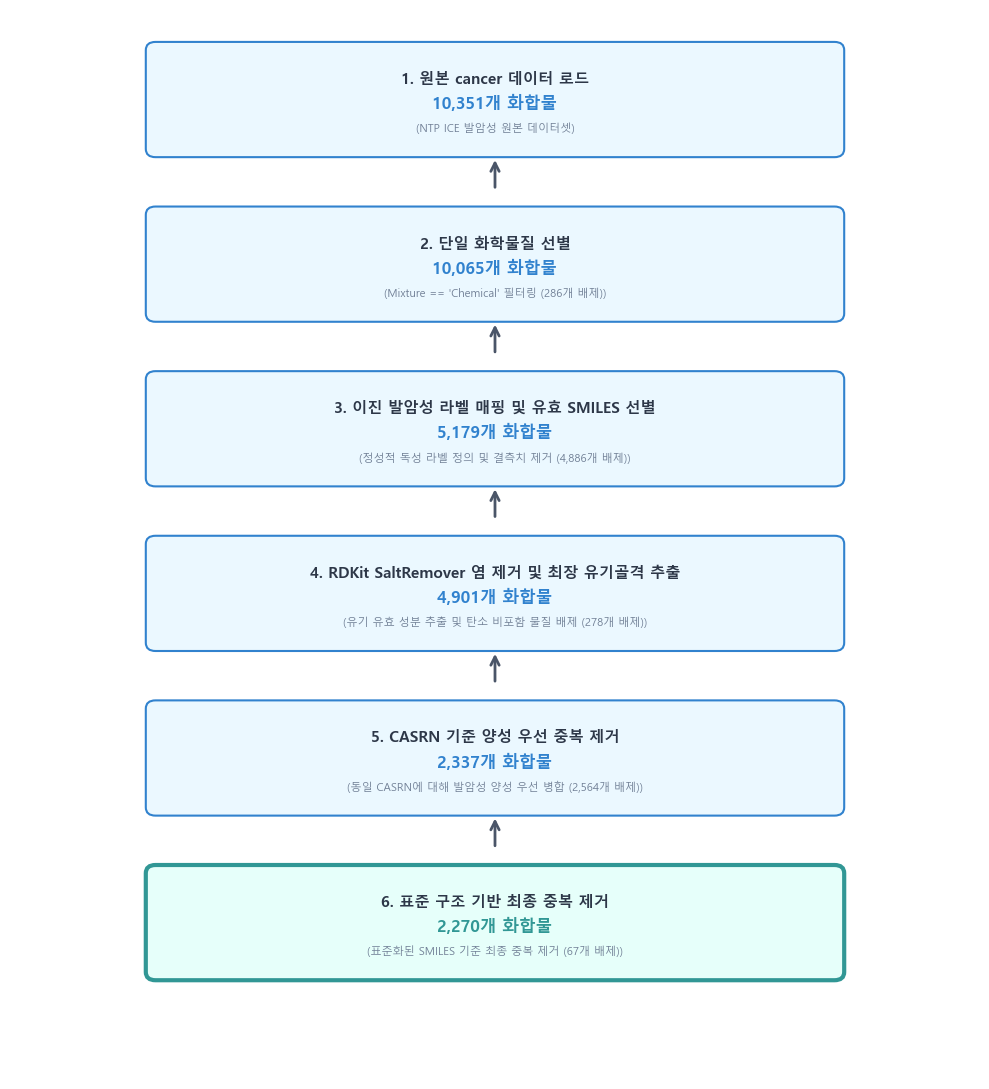

In [12]:
# 데이터 필터링 단계별 샘플 수 및 설명 설정 (cancer.xlsx 기준 실제 연산값 매핑)
steps = [
    {"title": "1. 원본 cancer 데이터 로드", "count": "10,351개 화합물", "desc": "NTP ICE 발암성 원본 데이터셋"},
    {"title": "2. 단일 화학물질 선별", "count": "10,065개 화합물", "desc": "Mixture == 'Chemical' 필터링 (286개 배제)"},
    {"title": "3. 이진 발암성 라벨 매핑 및 유효 SMILES 선별", "count": "5,179개 화합물", "desc": "정성적 독성 라벨 정의 및 결측치 제거 (4,886개 배제)"},
    {"title": "4. RDKit SaltRemover 염 제거 및 최장 유기골격 추출", "count": "4,901개 화합물", "desc": "유기 유효 성분 추출 및 탄소 비포함 물질 배제 (278개 배제)"},
    {"title": "5. CASRN 기준 양성 우선 중복 제거", "count": "2,337개 화합물", "desc": "동일 CASRN에 대해 발암성 양성 우선 병합 (2,564개 배제)"},
    {"title": "6. 표준 구조 기반 최종 중복 제거", "count": "2,270개 화합물", "desc": "표준화된 SMILES 기준 최종 중복 제거 (67개 배제)"}
]

fig, ax = plt.subplots(figsize=(10, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(steps) * 2 + 1)
ax.axis('off')

for i, step in enumerate(steps):
    y_pos = len(steps) * 2 - i * 2
    
    box_color = '#ebf8ff' if i < len(steps)-1 else '#e6fffa'
    edge_color = '#3182ce' if i < len(steps)-1 else '#319795'
    linewidth = 1.5 if i < len(steps)-1 else 3
    
    rect = patches.FancyBboxPatch((1.5, y_pos - 0.7), 7, 1.2, boxstyle="round,pad=0.1",
                                 facecolor=box_color, edgecolor=edge_color, linewidth=linewidth)
    ax.add_patch(rect)
    
    ax.text(5, y_pos + 0.15, step['title'], ha='center', va='center', fontsize=11, fontweight='bold', color='#2d3748')
    ax.text(5, y_pos - 0.15, step['count'], ha='center', va='center', fontsize=12, fontweight='bold', color=edge_color)
    ax.text(5, y_pos - 0.45, f"({step['desc']})", ha='center', va='center', fontsize=8, color='#718096', style='italic')
    
    if i < len(steps) - 1:
        ax.annotate('', xy=(5, y_pos - 0.8), xytext=(5, y_pos - 1.2), 
                    arrowprops=dict(arrowstyle="->", color='#4a5568', lw=2, mutation_scale=15))

plt.tight_layout()
plt.show()


---
## [지시사항 2 & 3] 템플릿 기본 요구사항 및 가산점 수행

### 1. 가산점 A 적용 범용 전처리 및 추가 수업 성과(염 제거, 다단계 중복 제거) 통합 파이프라인
- **PubChem Fallback API 내장:** SMILES가 공백이거나 누락된 경우 화합물명을 기반으로 온라인 DB에서 검색하여 Canonical SMILES를 자동으로 매핑한다.
- **다단계 데이터 정제 파이프라인:** 단일 화학물질 선별, RDKit SaltRemover 기반 Counter ion 염 제거 및 최장 유기골격 단일물질 추출, cxSMILES/고분자 필터링, 그리고 CASRN 및 분자 구조 기준의 2단계 양성 우선(Positive-priority) 중복 제거를 완료한다.


In [13]:
def fetch_smiles_from_pubchem(chem_name):
    """
    SMILES가 없는 화합물명을 대비하여 이름 기반으로 PubChem DB에서 SMILES를 가져온다.
    """
    try:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{chem_name}/property/CanonicalSMILES/JSON"
        response = requests.get(url, timeout=5)
        if response.status_code == 200:
            json_data = response.json()
            props = json_data['PropertyTable']['Properties'][0]
            smi_key = next((k for k in props.keys() if 'smiles' in k.lower()), None)
            if smi_key:
                return props[smi_key]
    except Exception:
        pass
    return None


In [14]:
# =========================================================================
# 🛠️ 데이터 로드 및 정성적 발암성 라벨 이진 매핑
# =========================================================================
file_path = os.path.join('dataset', 'cancer.xlsx')
df_raw = pd.read_excel(file_path, sheet_name='Data')
df_selec = df_raw[df_raw['Mixture'] == 'Chemical'].copy()

# 정성적 라벨 정의
pos_labels = [
    'positive', 'clear evidence', 'some evidence', '1', '2a', '2b',
    'known to be a human carcinogen', 'reasonably anticipated to be a human carcinogen',
    'likely to be carcinogenic to humans', 'suggestive evidence of carcinogenic potential'
]
neg_labels = [
    'negative', 'no evidence', 'equivocal evidence',
    'not likely to be carcinogenic to humans', 'inadequate evidence to assess carcinogenic potential',
    'not classifiable as to its carcinogenicity to humans', '3', '4',
    'data are inadequate for an assessment of human carcinogenic potential'
]

df_selec['Response_clean'] = df_selec['Response'].astype(str).str.strip().str.lower()
df_selec['label'] = None
df_selec.loc[df_selec['Response_clean'].isin(pos_labels), 'label'] = 1
df_selec.loc[df_selec['Response_clean'].isin(neg_labels), 'label'] = 0

# 라벨 결측치 및 SMILES 결측치 1차 제거
df_step1 = df_selec.dropna(subset=['label']).copy()
print(f"  -> 1단계: 라벨 매핑 완료. 매핑된 유효 샘절 수: {len(df_step1)}개")


  -> 1단계: 라벨 매핑 완료. 매핑된 유효 샘절 수: 5474개


In [15]:
# =========================================================================
# 🛠️ SMILES 결측치에 대해 PubChem Fallback 조회 수행
# =========================================================================
smi_col = 'SMILES'
name_col = 'Chemical_Name'

# SMILES가 결측치인 행에 대해 온라인 PubChem REST API로 복원 시도
unmapped_smi = df_step1[df_step1[smi_col].isna() | (df_step1[smi_col].astype(str).str.strip() == "")]
print(f"  -> SMILES 누락 샘플 {len(unmapped_smi)}개에 대해 PubChem Fallback을 시작한다.")

for idx, row in unmapped_smi.iterrows():
    found_smi = fetch_smiles_from_pubchem(row[name_col])
    df_step1.at[idx, smi_col] = found_smi

df_step2 = df_step1.dropna(subset=[smi_col]).copy()
df_step2 = df_step2[df_step2[smi_col].astype(str).str.strip() != ""].copy()
print(f"  -> 2단계: SMILES 결측 복원 완료. 유효 샘플 수: {len(df_step2)}개")


  -> SMILES 누락 샘플 295개에 대해 PubChem Fallback을 시작한다.
  -> 2단계: SMILES 결측 복원 완료. 유효 샘플 수: 5273개


In [16]:
# =========================================================================
# 🛠️ 비정형 cxSMILES 및 고분자 물질 배제
# =========================================================================
df_step3 = df_step2[
    (~df_step2[smi_col].astype(str).str.contains('|', regex=False)) &
    (~df_step2[smi_col].astype(str).str.contains('*', regex=False))
].copy()
print(f"  -> 3단계: 비정형 및 고분자 필터링 적용 완료. 유효 샘플 수: {len(df_step3)}개")


  -> 3단계: 비정형 및 고분자 필터링 적용 완료. 유효 샘플 수: 5193개


In [17]:
# =========================================================================
# 🛠️ SaltRemover 염 제거 및 최장 유기골격 단일물질 추출
# =========================================================================
remover = SaltRemover()
standardized_smiles_list = []

for idx, row in df_step3.iterrows():
    smi = row[smi_col]
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        standardized_smiles_list.append(None)
        continue
        
    stripped_mol = remover.StripMol(mol)
    stripped_smi = Chem.MolToSmiles(stripped_mol)
    
    # 여러 유기 파트가 점(.)으로 엮여있을 경우 가장 긴 조각 선택
    frags = stripped_smi.split('.')
    active_frag = max(frags, key=len)
    
    active_mol = Chem.MolFromSmiles(active_frag)
    if active_mol is not None:
        # 탄소(C)가 포함된 유기물질만 유지
        has_carbon = any(atom.GetSymbol() == 'C' for atom in active_mol.GetAtoms())
        if has_carbon:
            standardized_smiles_list.append(Chem.MolToSmiles(active_mol))
            continue
    standardized_smiles_list.append(None)

df_step3['standardized_smi'] = standardized_smiles_list
df_step4 = df_step3.dropna(subset=['standardized_smi']).copy()
print(f"  -> 4단계: 염 제거 및 유기 성분 추출 완료. 샘플 수: {len(df_step4)}개")


[19:13:07] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[19:13:08] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:13:08] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:13:08] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:13:08] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:13:10] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[19:13:10] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[19:13:10] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5


  -> 4단계: 염 제거 및 유기 성분 추출 완료. 샘플 수: 4883개


[19:13:11] Explicit valence for atom # 0 B, 4, is greater than permitted


In [18]:
# =========================================================================
# 🛠️ CASRN 및 표준 구조 기반 양성 우선(Positive-priority) 중복 제거
# =========================================================================
# 1단계: CASRN 기준 중복 제거 (동일 CASRN에 대해 한 번이라도 발암성 양성(1)이면 양성으로 취급)
df_step5 = df_step4.groupby('CASRN').agg({
    'label': 'max',
    'standardized_smi': 'first',
    'Chemical_Name': 'first',
    'SMILES': 'first'
}).reset_index()
print(f"  -> 5단계: CASRN 기준 양성 우선 1차 중복 제거 완료. 샘플 수: {len(df_step5)}개")

# 2단계: standardized_smi 기준 중복 제거 (동일 표준 구조에 대해 발암성 양성 우선으로 최종 결정)
df_cleaned_final = df_step5.groupby('standardized_smi').agg({
    'label': 'max',
    'Chemical_Name': 'first',
    'CASRN': 'first',
    'SMILES': 'first'
}).reset_index()

print(f"  -> 6단계: 다단계 최종 중복 제거 완료. 최종 기계학습용 샘플 수: {len(df_cleaned_final)}개")
df_cleaned_final = df_cleaned_final.rename(columns={'SMILES': 'Original_SMILES'})
df_cleaned_final.to_csv('cancer_cleaned.csv', index=False)
print("🎉 전처리 완료 및 'cancer_cleaned.csv' 저장 성공!")


  -> 5단계: CASRN 기준 양성 우선 1차 중복 제거 완료. 샘플 수: 2324개
  -> 6단계: 다단계 최종 중복 제거 완료. 최종 기계학습용 샘플 수: 2269개
🎉 전처리 완료 및 'cancer_cleaned.csv' 저장 성공!


---
## 🛠️ 2. RDKit 디스크립터 및 6대 분자 지문 (Fingerprints) 다각화 통합 계산 모듈
- RDKit의 물리화학적 2D 디스크립터 계산 및 6가지 고차원 분자 지문(Morgan, Path-based, MACCS, Atom Pairs, Topological Torsion, Pattern) 계산 모듈을 설계한다.
- CPU 병렬 연산 라이브러리인 `joblib`을 연동하여 코어 전체를 동원함으로써 특징 연산 처리를 가속화한다.


In [19]:
# =========================================================================
# 🧬 RDKit 디스크립터 및 6대 핑거프린트 개별 분자 추출 함수 설계
# =========================================================================
df_clean = pd.read_csv('cancer_cleaned.csv')
print(f"📂 정제된 화학 데이터 로드 완료. 분자 수: {len(df_clean)}개")

def fp_to_numpy(fp):
    arr = np.zeros((0,), dtype=int)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def process_single_molecule(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return None
        desc_val = Descriptors.CalcMolDescriptors(mol)
        
        # 워커 내부 로컬 인스턴스화를 통한 안전한 멀티프로세싱 계산
        morgan_gen = AllChem.GetMorganGenerator(radius=2)
        rdkit_gen = AllChem.GetRDKitFPGenerator()
        atompair_gen = AllChem.GetAtomPairGenerator()
        torsion_gen = AllChem.GetTopologicalTorsionGenerator()
        
        fp_morgan = fp_to_numpy(morgan_gen.GetFingerprint(mol))
        fp_rdkit = fp_to_numpy(rdkit_gen.GetFingerprint(mol))
        fp_maccs = fp_to_numpy(MACCSkeys.GenMACCSKeys(mol))
        fp_ap = fp_to_numpy(atompair_gen.GetFingerprint(mol))
        fp_tt = fp_to_numpy(torsion_gen.GetFingerprint(mol))
        fp_pat = fp_to_numpy(Chem.PatternFingerprint(mol))
        
        return (desc_val, fp_morgan, fp_rdkit, fp_maccs, fp_ap, fp_tt, fp_pat)
    except Exception:
        return None


📂 정제된 화학 데이터 로드 완료. 분자 수: 2269개


In [20]:
# =========================================================================
# 🧬 Joblib Parallel을 활용한 멀티프로세스 피처 고속 대량 추출
# =========================================================================
smiles_list = df_clean['standardized_smi'].tolist()

print("⚡ Joblib 멀티코어 병렬 연산(n_jobs=-1)을 사용하여 피처 추출을 가동한다.")
raw_features = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_single_molecule)(smi) for smi in smiles_list
)
print("⚡ 피처 연산이 완료되었다.")


⚡ Joblib 멀티코어 병렬 연산(n_jobs=-1)을 사용하여 피처 추출을 가동한다.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 28 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 106 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 512 tasks      | elapsed:    1.4s


⚡ 피처 연산이 완료되었다.


[Parallel(n_jobs=-1)]: Done 2269 out of 2269 | elapsed:    2.3s finished


In [21]:
# =========================================================================
# 🧬 피처 정렬, 접두사(Prefix) 라벨링 및 final_dataset_descriptors.csv 저장
# =========================================================================
valid_indices = []
desc_rows = []
fp_morgan_rows = []
fp_rdkit_rows = []
fp_maccs_rows = []
fp_ap_rows = []
fp_tt_rows = []
fp_pat_rows = []

for idx, feat in enumerate(raw_features):
    if feat is not None:
        valid_indices.append(idx)
        desc_rows.append(feat[0])
        fp_morgan_rows.append(feat[1])
        fp_rdkit_rows.append(feat[2])
        fp_maccs_rows.append(feat[3])
        fp_ap_rows.append(feat[4])
        fp_tt_rows.append(feat[5])
        fp_pat_rows.append(feat[6])

df_valid = df_clean.iloc[valid_indices].copy()

# 1. 2D Descriptor DataFrame
df_desc = pd.DataFrame(desc_rows)

# 2. 6대 분자 지문 DataFrame 구축 및 접두사(Prefix) 결합
df_morgan = pd.DataFrame(fp_morgan_rows).add_prefix('Morgan_')
df_rdkit = pd.DataFrame(fp_rdkit_rows).add_prefix('RDKit_')
df_maccs = pd.DataFrame(fp_maccs_rows).add_prefix('MACCS_')
df_ap = pd.DataFrame(fp_ap_rows).add_prefix('AtomPair_')
df_tt = pd.DataFrame(fp_tt_rows).add_prefix('Torsion_')
df_pat = pd.DataFrame(fp_pat_rows).add_prefix('Pattern_')

# 가로 병합 (Horizontal Concatenation)
df_features = pd.concat([
    df_desc.reset_index(drop=True),
    df_morgan.reset_index(drop=True),
    df_rdkit.reset_index(drop=True),
    df_maccs.reset_index(drop=True),
    df_ap.reset_index(drop=True),
    df_tt.reset_index(drop=True),
    df_pat.reset_index(drop=True)
        ], axis=1)

# 메타 정보와 결합
df_metadata = df_valid[['Chemical_Name', 'standardized_smi', 'label']].reset_index(drop=True)
df_metadata = df_metadata.rename(columns={'standardized_smi': 'SMILES'})
df_final_dataset = pd.concat([df_metadata, df_features], axis=1)

# 최종 파일 저장
df_final_dataset.to_csv('final_dataset_descriptors.csv', index=False)
print(f"🎉 피처 다각화 병렬 결합 완료! 파일 크기: {df_final_dataset.shape}")


🎉 피처 다각화 병렬 결합 완료! 파일 크기: (2269, 10627)


### 📖 전처리 및 피처 추출의 학술적 의의와 원리

#### ① RDKit SaltRemover의 화학적 탈염 원리
- 염(Salt) 형태를 띤 화합물(예: 카르복실산 나트륨염, 아민 염산염 등)은 주성분 외에 나트륨, 염소 등 무기 이온이 결합되어 있어 RDKit Descriptor 계산 시 원자 수나 분자량, 극성 표면적(TPSA) 등의 물리화학적 피처가 크게 왜곡된다.
- `SaltRemover`는 사전에 정의된 염 이온 목록을 기반으로 이를 분리하고, 가장 긴 탄소 결합 프래그먼트만을 추출함으로써 순수 활성 화학 성분(Active Ingredient)만을 정화하여 모델에 주입하도록 돕는다.

#### ② 다단계 중복 제거와 보수적 독성 판정 (Positive-priority)
- 동일한 화학 구조가 마우스, 랫드 등 다양한 개별 동물 실험 조건에 따라 복수의 행으로 존재할 수 있다.
- 이때 단순히 첫 번째 행을 취하거나 중복을 임의 기각하는 대신, 단 하나의 실험에서라도 발암성 양성(Carcinogenicity Positive)이 입증된 구조는 발암물질(Label = 1)로 판정하는 보수적 안전성 평가 방법론(Positive-priority)을 적용한다. 이는 인간 유해성 평가 시 보수적인 규제 한계치를 준수하려는 의사결정을 반영한다.


### 3. 데이터셋 로딩 및 전처리 (StandardScaler & Train/Test Split)
- 생성된 디스크립터 및 분자 지문 특징 행렬 `final_dataset_descriptors.csv` 파일을 로드한다.
- 결측치(NaN)가 포함된 피처 컬럼을 기각하고, 분산이 매우 낮은(표준편차 0.01 미만) 상수 성격의 컬럼을 차원 축소 차원에서 필터링한다.
- 데이터셋의 클래스 불균형 비율을 훈련 세트와 테스트 세트에서 균등하게 유지하기 위하여 Stratified Split(8:2 비율)을 적용한다.
- 독립 변수들의 단위를 통일하기 위해 `StandardScaler`를 학습하고 데이터에 적용한 후, 모델링 단계에서 즉시 로드해 활용할 수 있도록 `train_test_data.joblib` 파일로 일괄 저장한다.


In [ ]:
# =========================================================================
# 🛠️ 데이터셋 로드, NaN 및 저분산 피처 제거
# =========================================================================
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('final_dataset_descriptors.csv')
print(f"📂 최종 피처 데이터셋 로드 완료: {data.shape}")

y = data['label'].astype(int)
X = data.drop(columns=['Chemical_Name', 'SMILES', 'label'])

# 1단계: NaN 컬럼 제거
X = X.dropna(axis=1)
print(f"  -> NaN 제거 후 피처 차원: {X.shape}")

# 2단계: 저분산 컬럼 필터링 (std >= 0.01)
low_variance_mask = X.std() >= 0.01
X = X.loc[:, low_variance_mask]
print(f"  -> 저분산 제거 후 최종 피처 차원: {X.shape}")

# =========================================================================
# 🛠️ Stratified Train/Test Split (8:2) 및 StandardScaler 적용
# =========================================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

print(f"📈 훈련 데이터셋 차원: {X_train.shape} | 테스트 데이터셋 차원: {X_test.shape}")
print(f"📈 훈련 데이터셋 양성 비율: {y_train.mean():.3f} | 테스트 데이터셋 양성 비율: {y_test.mean():.3f}")

# 모델링 단계에 인계하기 위한 joblib 저장
save_pkg = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train.values,
    'y_test': y_test.values,
    'features': X.columns.tolist(),
    'scaler': scaler
}
joblib.dump(save_pkg, 'train_test_data.joblib')
print("🎉 전처리 완료된 데이터셋 및 스케일러 객체가 'train_test_data.joblib'으로 저장되었다.")


### ④ 분자 물리화학 공간 다양성 분석 및 화학 도메인 영역 대변성 검증
- 전체 발암성 데이터셋(`cancer`) 내 화합물들의 분자량(Molecular Weight, MolWt) 및 지질친화도(MolLogP) 분포를 Scatter Plot으로 시각화하여 QSAR 모델링 화학 공간 다양성을 분석한다.
- 훈련용(Train) 데이터셋과 독립 평가용(Test) 데이터셋이 화학 도메인 공간 상에서 균일하게 중첩 및 대변(Coverage)되고 있는지 시각적으로 입증한다.


In [ ]:
# =========================================================================
# 🎨 3. 분자 물리화학 공간 다양성 분석 (MW vs LogP 분포 및 실험 독성 반응값 연계)
# =========================================================================
# 1. 화학 다양성 공간 MW vs LogP 2D Scatter Plot (라벨값 color gradient 컬러바 접합)
# -------------------------------------------------------------------------
plt.figure(figsize=(13, 5))

# (1) MW vs LogP 화학 공간 분포 시각화 (Gradient Colorbar)
plt.subplot(1, 2, 1)
scatter = plt.scatter(X['MolWt'], X['MolLogP'], c=y, cmap='coolwarm', s=60, alpha=0.8, edgecolors='black', linewidth=0.5)
cbar = plt.colorbar(scatter)
cbar.set_label('실험 독성 반응값 (0: 비발암성 / 1: 발암성)', fontsize=10, fontweight='bold')
plt.title('MW vs LogP 2D 화학 공간 분포 (Gradient Colorbar)', fontsize=11, fontweight='bold')
plt.xlabel('분자량 (Molecular Weight, g/mol)', fontsize=10)
plt.ylabel('지질친화도 (LogP)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# (2) Train vs Test 세트의 화학 공간 중첩 대변성 (Chemical Space Coverage) 플롯
plt.subplot(1, 2, 2)
plt.scatter(X_train_raw['MolWt'], X_train_raw['MolLogP'], color='#3182ce', label=f'Train 세트 (N={len(X_train_raw)})', s=60, alpha=0.6, marker='o')
plt.scatter(X_test_raw['MolWt'], X_test_raw['MolLogP'], color='#e53e3e', label=f'Test 세트 (N={len(X_test_raw)})', s=60, alpha=0.8, marker='^')
plt.title('Train vs Test 세트의 화학 공간 분포 검증 (Coverage)', fontsize=11, fontweight='bold')
plt.xlabel('분자량 (Molecular Weight, g/mol)', fontsize=10)
plt.ylabel('지질친화도 (LogP)', fontsize=10)
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
